<a href="https://colab.research.google.com/github/JUANK026/MODELO-DE-CLASIFICACI-N-DE-DIAGN-STICOS-M-DICOS/blob/main/deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UNIVERSIDAD MILITAR NUEVA GRANADA
Facultad de Ingeniería | Deep Learning
Proyecto 1: Modelo de Clasificación de Diagnósticos Médicos mediante Red Neuronal MLP
Dataset: Exámenes de Laboratorio de Consulta Externa – EsSalud (2024)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [ ]:
RUTA = '/content/Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Obesidad_202405_202411.csv'

df = pd.read_csv(RUTA, sep=';', encoding='latin-1')

print(f'Shape original: {df.shape}')
print(f'\nColumnas ({len(df.columns)}):')
print(df.columns.tolist())
df.head(3)

Shape original: (63799, 28)

Columnas (28):
['FECHA_CORTE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'UBIGEO', 'RED', 'IPRESS', 'ID_PACIENTE', 'EDAD_PACIENTE', 'SEXO_PACIENTE', 'EDAD_MEDICO', 'ID_MEDICO', 'COD_DIAG', 'DIAGNOSTICO', 'AREA_HOSPITALARIA', 'SERVICIO_HOSPITALARIO', 'ACTIVIDAD_HOSPITALARIA', 'FECHA_MUESTRA', 'FEC_RESULTADO_1', 'DIFERIMIENTO_1', 'PROCEDIMIENTO_1', 'RESULTADO_1', 'UNIDADES_1', 'FEC_RESULTADO_2', 'PROCEDIMIENTO_2', 'RESULTADO_2', 'UNIDADES_2', 'DIFERIMIENTO_2']


,FECHA_CORTE,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,RED,IPRESS,ID_PACIENTE,EDAD_PACIENTE,SEXO_PACIENTE,...,FEC_RESULTADO_1,DIFERIMIENTO_1,PROCEDIMIENTO_1,RESULTADO_1,UNIDADES_1,FEC_RESULTADO_2,PROCEDIMIENTO_2,RESULTADO_2,UNIDADES_2,DIFERIMIENTO_2
0,20241204,LIMA,LIMA,MIRAFLORES,150122,RED ASISTENCIAL REBAGLIATI,H.III SUAREZ-ANGAMOS,eJwzNDSyNDe0MLcwNjM1NrI0MAAAH10DeQ==,64,FEMENINO,...,20240503,79,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",106.00,mg/dL,20240503,TRIGLICERIDOS,273.0,mg/dL,79
1,20241204,LA LIBERTAD,TRUJILLO,VICTOR LARCO HERRERA,130111,RED ASISTENCIAL LA LIBERTAD,POL. VICTOR LARCO HERRERA,eJwzNrS0NLAwM7YwsjAwNAACAB9eA2s=,9,MASCULINO,...,20240504,70,TRIGLICERIDOS,57.00,mg/dL,20240504,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",84.0,mg/dL,70
2,20241204,CAJAMARCA,JAEN,JAEN,60801,RED ASISTENCIAL JAEN,H.II JAEN,eJwzNDYzNjY3M7A0Njc0MLcwsAQAHyADeg==,47,FEMENINO,...,20240518,82,"DOSAJE DE GLUCOSA EN SANGRE, CUANTITATIVO (EXC...",90.83,mg/dL,20240518,TRIGLICERIDOS,54.9,mg/dL,82


In [ ]:
print('=' * 55)
print('TIPOS DE DATOS')
print('=' * 55)
print(df.dtypes)

print('\n' + '=' * 55)
print('VALORES NULOS')
print('=' * 55)
print(df.isnull().sum())

print('\n' + '=' * 55)
print('ESTADÍSTICAS DESCRIPTIVAS')
print('=' * 55)
df.describe()

TIPOS DE DATOS
FECHA_CORTE                 int64
DEPARTAMENTO               object
PROVINCIA                  object
DISTRITO                   object
UBIGEO                      int64
RED                        object
IPRESS                     object
ID_PACIENTE                object
EDAD_PACIENTE               int64
SEXO_PACIENTE              object
EDAD_MEDICO                 int64
ID_MEDICO                  object
COD_DIAG                   object
DIAGNOSTICO                object
AREA_HOSPITALARIA          object
SERVICIO_HOSPITALARIO      object
ACTIVIDAD_HOSPITALARIA     object
FECHA_MUESTRA               int64
FEC_RESULTADO_1             int64
DIFERIMIENTO_1              int64
PROCEDIMIENTO_1            object
RESULTADO_1               float64
UNIDADES_1                 object
FEC_RESULTADO_2             int64
PROCEDIMIENTO_2            object
RESULTADO_2               float64
UNIDADES_2                 object
DIFERIMIENTO_2              int64
dtype: object

VALORES NULOS
FECH

,FECHA_CORTE,UBIGEO,EDAD_PACIENTE,EDAD_MEDICO,FECHA_MUESTRA,FEC_RESULTADO_1,DIFERIMIENTO_1,RESULTADO_1,FEC_RESULTADO_2,RESULTADO_2,DIFERIMIENTO_2
count,63799.0,63799.000000,63799.000000,63799.000000,6.379900e+04,6.379900e+04,63799.000000,63799.000000,6.379900e+04,63799.000000,63799.000000
mean,20241204.0,127856.792552,49.656107,46.414944,2.024087e+07,2.024087e+07,0.752128,128.210719,2.024087e+07,130.010162,0.752034
std,0.0,53102.685392,20.919090,11.655568,1.854653e+02,1.847756e+02,3.274059,72.058901,1.847789e+02,74.019124,3.261037
min,20241204.0,10101.000000,0.000000,24.000000,2.024021e+07,2.024050e+07,0.000000,0.000000,2.024050e+07,0.000000,0.000000
25%,20241204.0,100101.000000,37.000000,37.000000,2.024072e+07,2.024072e+07,0.000000,90.000000,2.024072e+07,90.155000,0.000000
50%,20241204.0,150101.000000,53.000000,45.000000,2.024091e+07,2.024091e+07,0.000000,103.000000,2.024091e+07,104.000000,0.000000
75%,20241204.0,150132.000000,65.000000,56.000000,2.024102e+07,2.024102e+07,0.000000,143.595000,2.024102e+07,148.000000,0.000000
max,20241204.0,240101.000000,102.000000,80.000000,2.024113e+07,2.024113e+07,82.000000,990.000000,2.024113e+07,997.000000,82.000000


Distribución de COD_DIAG (variable objetivo):
COD_DIAG
E03.9    26004
E66.9    19688
E66.3     9601
E66.0     7971
E66.8      444
Z71.3       48
E66.2       23
E66.1       16
E23.6        4
Name: count, dtype: int64


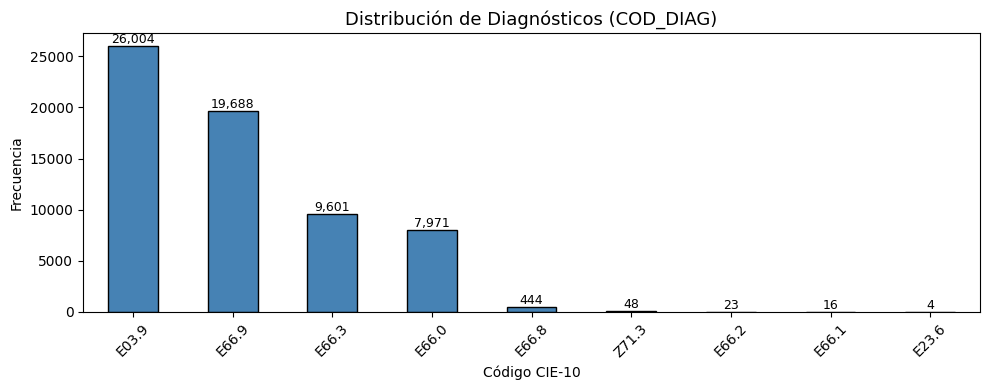

In [ ]:
# Distribución de la variable objetivo
print('Distribución de COD_DIAG (variable objetivo):')
print(df['COD_DIAG'].value_counts())

fig, ax = plt.subplots(figsize=(10, 4))
df['COD_DIAG'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribución de Diagnósticos (COD_DIAG)', fontsize=13)
ax.set_xlabel('Código CIE-10')
ax.set_ylabel('Frecuencia')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_clean = df.copy()

# 3.1 Eliminar duplicados
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplicados eliminados: {n_before - len(df_clean)}')

# 3.2 Eliminar columnas irrelevantes para el modelo
# - FECHA_CORTE:           fecha de corte del reporte (no es variable clínica)
# - ID_PACIENTE:           identificador anonimizado (no aporta al modelo)
# - ID_MEDICO:             identificador anonimizado
# - UBIGEO:                código geográfico de alta cardinalidad
# - DIAGNOSTICO:           descripción textual redundante con COD_DIAG
# - AREA_HOSPITALARIA:     valor único ('CONSULTA EXTERNA') en todo el dataset
# - ACTIVIDAD_HOSPITALARIA: valor único en todo el dataset
# - FECHA_MUESTRA, FEC_RESULTADO_1, FEC_RESULTADO_2: fechas crudas no útiles

cols_drop = [
    'FECHA_CORTE', 'ID_PACIENTE', 'ID_MEDICO', 'UBIGEO',
    'DIAGNOSTICO', 'AREA_HOSPITALARIA', 'ACTIVIDAD_HOSPITALARIA',
    'FECHA_MUESTRA', 'FEC_RESULTADO_1', 'FEC_RESULTADO_2'
]
df_clean = df_clean.drop(columns=cols_drop)
print(f'Columnas eliminadas: {cols_drop}')
print(f'Columnas restantes: {df_clean.columns.tolist()}')

Duplicados eliminados: 1
Columnas eliminadas: ['FECHA_CORTE', 'ID_PACIENTE', 'ID_MEDICO', 'UBIGEO', 'DIAGNOSTICO', 'AREA_HOSPITALARIA', 'ACTIVIDAD_HOSPITALARIA', 'FECHA_MUESTRA', 'FEC_RESULTADO_1', 'FEC_RESULTADO_2']
Columnas restantes: ['DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'RED', 'IPRESS', 'EDAD_PACIENTE', 'SEXO_PACIENTE', 'EDAD_MEDICO', 'COD_DIAG', 'SERVICIO_HOSPITALARIO', 'DIFERIMIENTO_1', 'PROCEDIMIENTO_1', 'RESULTADO_1', 'UNIDADES_1', 'PROCEDIMIENTO_2', 'RESULTADO_2', 'UNIDADES_2', 'DIFERIMIENTO_2']


In [ ]:
# 3.3 Verificar valores negativos en columnas numéricas clínicas
num_cols = ['EDAD_PACIENTE', 'EDAD_MEDICO', 'DIFERIMIENTO_1', 'DIFERIMIENTO_2',
            'RESULTADO_1', 'RESULTADO_2']

for col in num_cols:
    n_neg = (df_clean[col] < 0).sum()
    print(f'{col}: {n_neg} valores negativos')
    if n_neg > 0:
        df_clean = df_clean[df_clean[col] >= 0]

print(f'\nShape tras limpieza: {df_clean.shape}')

EDAD_PACIENTE: 0 valores negativos
EDAD_MEDICO: 0 valores negativos
DIFERIMIENTO_1: 0 valores negativos
DIFERIMIENTO_2: 0 valores negativos
RESULTADO_1: 0 valores negativos
RESULTADO_2: 0 valores negativos

Shape tras limpieza: (63798, 18)


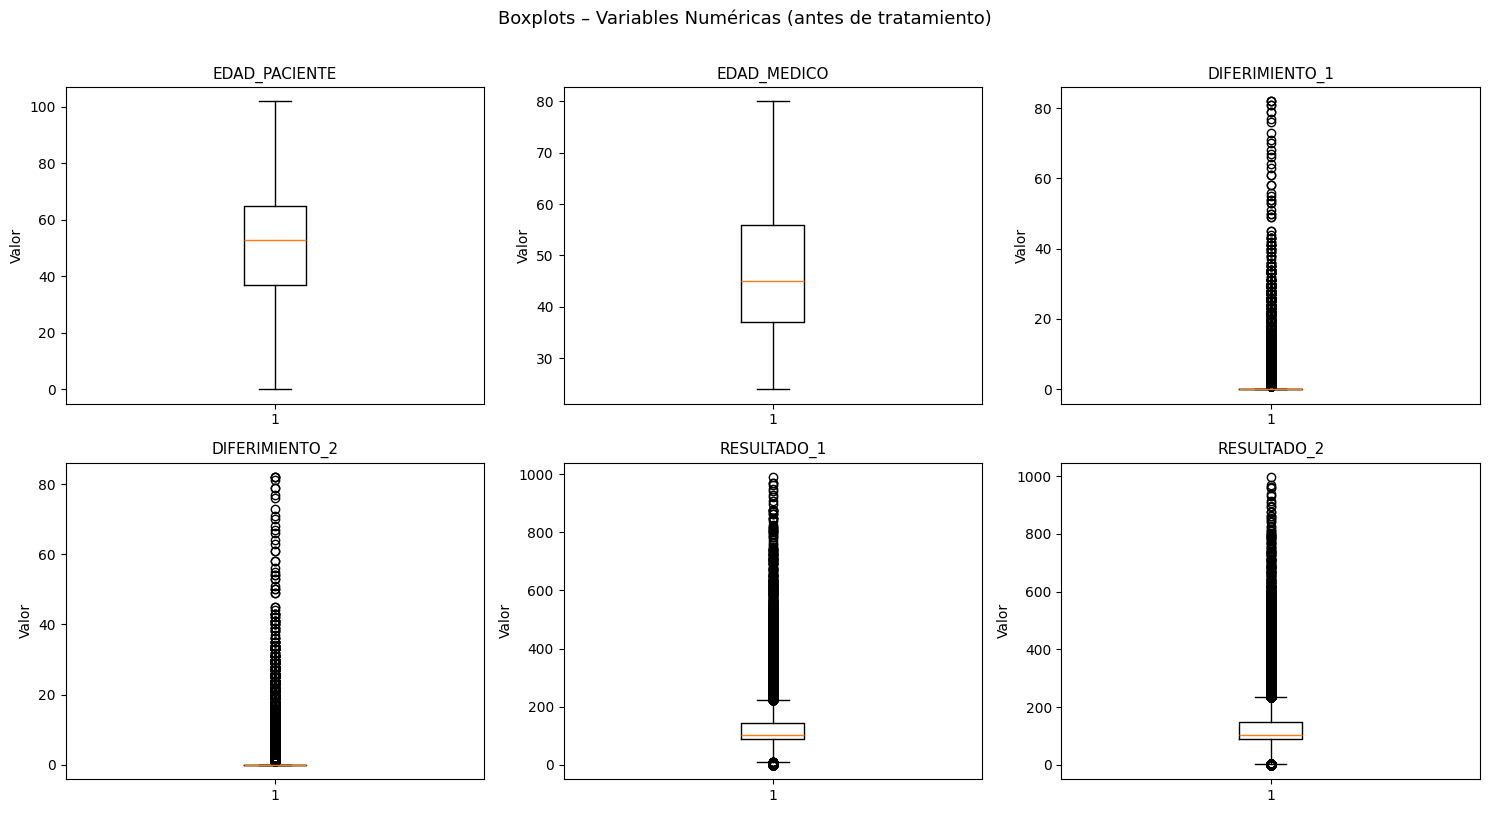

In [ ]:
# Visualizar distribución antes del tratamiento
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots – Variables Numéricas (antes de tratamiento)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Winsorización con IQR (capping)
cols_outlier = ['RESULTADO_1', 'RESULTADO_2', 'DIFERIMIENTO_1', 'DIFERIMIENTO_2']

for col in cols_outlier:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f'{col}: {n_out} outliers capados en [{lower:.2f}, {upper:.2f}]')

RESULTADO_1: 6281 outliers capados en [9.60, 223.99]
RESULTADO_2: 5474 outliers capados en [3.38, 234.77]
DIFERIMIENTO_1: 9285 outliers capados en [0.00, 0.00]
DIFERIMIENTO_2: 9334 outliers capados en [0.00, 0.00]


In [ ]:
label_encoders = {}

# Features categóricas
cat_features = [
    'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO',
    'RED', 'IPRESS',
    'SEXO_PACIENTE',
    'SERVICIO_HOSPITALARIO',
    'PROCEDIMIENTO_1', 'UNIDADES_1',
    'PROCEDIMIENTO_2', 'UNIDADES_2'
]

for col in cat_features:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {len(le.classes_)} categorías -> LabelEncoder aplicado')

# Codificar la variable objetivo
le_target = LabelEncoder()
df_clean['TARGET'] = le_target.fit_transform(df_clean['COD_DIAG'].astype(str))
label_encoders['COD_DIAG'] = le_target

print(f'\nClases del TARGET:')
for i, cls in enumerate(le_target.classes_):
    print(f'  {i} → {cls}')

# Eliminar columna original del target
df_clean = df_clean.drop(columns=['COD_DIAG'])

  DEPARTAMENTO: 24 categorías -> LabelEncoder aplicado
  PROVINCIA: 98 categorías -> LabelEncoder aplicado
  DISTRITO: 197 categorías -> LabelEncoder aplicado
  RED: 29 categorías -> LabelEncoder aplicado
  IPRESS: 241 categorías -> LabelEncoder aplicado
  SEXO_PACIENTE: 2 categorías -> LabelEncoder aplicado
  SERVICIO_HOSPITALARIO: 43 categorías -> LabelEncoder aplicado
  PROCEDIMIENTO_1: 2 categorías -> LabelEncoder aplicado
  UNIDADES_1: 2 categorías -> LabelEncoder aplicado
  PROCEDIMIENTO_2: 2 categorías -> LabelEncoder aplicado
  UNIDADES_2: 2 categorías -> LabelEncoder aplicado

Clases del TARGET:
  0 → E03.9
  1 → E23.6
  2 → E66.0
  3 → E66.1
  4 → E66.2
  5 → E66.3
  6 → E66.8
  7 → E66.9
  8 → Z71.3


In [ ]:
feature_cols = [c for c in df_clean.columns if c != 'TARGET']

scaler = StandardScaler()
df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])

print(f'StandardScaler aplicado a {len(feature_cols)} features:')
print(feature_cols)

StandardScaler aplicado a 17 features:
['DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'RED', 'IPRESS', 'EDAD_PACIENTE', 'SEXO_PACIENTE', 'EDAD_MEDICO', 'SERVICIO_HOSPITALARIO', 'DIFERIMIENTO_1', 'PROCEDIMIENTO_1', 'RESULTADO_1', 'UNIDADES_1', 'PROCEDIMIENTO_2', 'RESULTADO_2', 'UNIDADES_2', 'DIFERIMIENTO_2']


In [ ]:
print('=' * 55)
print('RESUMEN FINAL DEL PREPROCESAMIENTO')
print('=' * 55)
print(f'Shape final:           {df_clean.shape}')
print(f'Valores nulos totales: {df_clean.isnull().sum().sum()}')
print(f'Número de features:    {len(feature_cols)}')
print(f'Número de clases:      {df_clean["TARGET"].nunique()}')
print(f'\nClases y conteo:')
print(df_clean['TARGET'].value_counts().sort_index())
df_clean.head()

RESUMEN FINAL DEL PREPROCESAMIENTO
Shape final:           (63798, 18)
Valores nulos totales: 0
Número de features:    17
Número de clases:      9

Clases y conteo:
TARGET
0    26003
1        4
2     7971
3       16
4       23
5     9601
6      444
7    19688
8       48
Name: count, dtype: int64


,DEPARTAMENTO,PROVINCIA,DISTRITO,RED,IPRESS,EDAD_PACIENTE,SEXO_PACIENTE,EDAD_MEDICO,SERVICIO_HOSPITALARIO,DIFERIMIENTO_1,PROCEDIMIENTO_1,RESULTADO_1,UNIDADES_1,PROCEDIMIENTO_2,RESULTADO_2,UNIDADES_2,DIFERIMIENTO_2,TARGET
0,0.420500,0.272116,0.281228,1.009698,0.460983,0.685690,-0.634010,0.307565,-1.486392,0.0,-0.953193,-0.311207,-0.105403,0.953193,2.180716,-0.105403,0.0,0
1,0.044542,1.500636,1.632017,0.153953,1.592177,-1.943489,1.577262,0.736552,2.032294,0.0,1.049105,-1.333691,-0.105403,-1.049105,-0.764559,-0.105403,0.0,5
2,-1.271312,-0.044921,-0.295109,-0.166951,0.155740,-0.126965,-0.634010,-0.807801,0.333618,0.0,-0.953193,-0.627760,-0.105403,0.953193,-1.333019,-0.105403,0.0,7
3,0.420500,0.272116,1.019659,-1.450568,-0.706122,-1.800080,-0.634010,1.337134,2.032294,0.0,-0.953193,-0.791148,-0.105403,0.953193,-0.745024,-0.105403,0.0,7
4,-1.083333,-1.590478,1.614007,1.116666,-1.208875,-2.278112,1.577262,-0.035625,2.032294,0.0,1.049105,1.024281,-0.105403,-1.049105,-0.198052,-0.105403,0.0,7


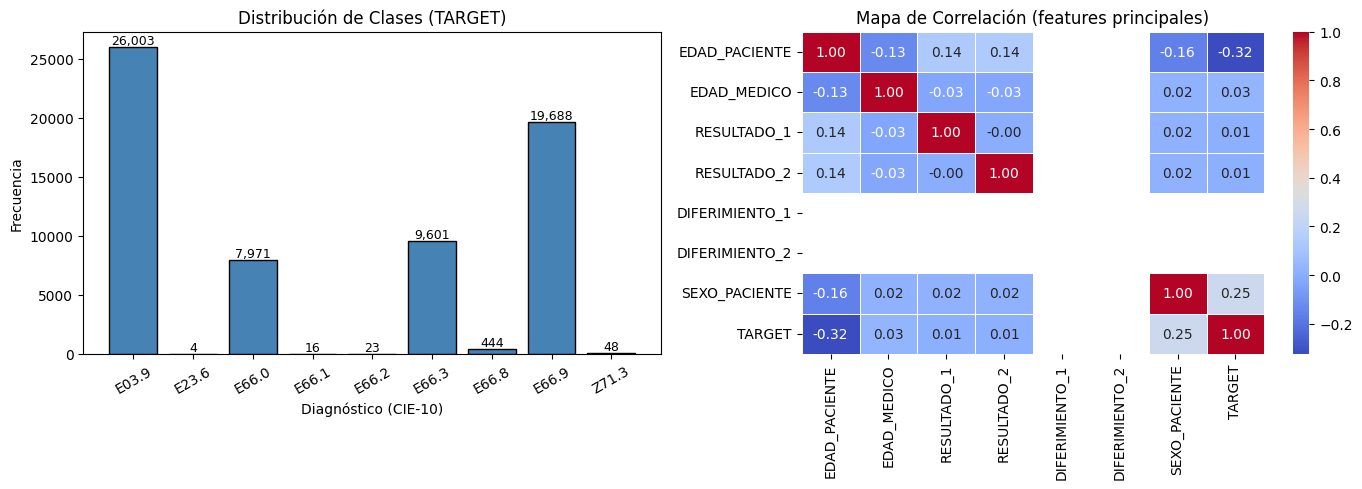

In [ ]:
# Visualización final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo de clases
counts = df_clean['TARGET'].value_counts().sort_index()
clases_label = le_target.inverse_transform(counts.index)
axes[0].bar(clases_label, counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Clases (TARGET)', fontsize=12)
axes[0].set_xlabel('Diagnóstico (CIE-10)')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Mapa de correlación
corr_cols = ['EDAD_PACIENTE', 'EDAD_MEDICO', 'RESULTADO_1', 'RESULTADO_2',
             'DIFERIMIENTO_1', 'DIFERIMIENTO_2', 'SEXO_PACIENTE', 'TARGET']
corr = df_clean[corr_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
axes[1].set_title('Mapa de Correlación (features principales)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
df_clean.to_csv('dataset_procesado.csv', index=False)
print('✅ dataset_procesado.csv guardado')

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
print('✅ scaler.pkl guardado')
print('✅ label_encoders.pkl guardado')

print(f'\n📊 Dataset listo para modelado:')
print(f'   - Registros:  {len(df_clean):,}')
print(f'   - Features:   {len(feature_cols)}')
print(f'   - Clases:     {df_clean["TARGET"].nunique()}')

✅ dataset_procesado.csv guardado
✅ scaler.pkl guardado
✅ label_encoders.pkl guardado

📊 Dataset listo para modelado:
   - Registros:  63,798
   - Features:   17
   - Clases:     9


# 2.Aplique aleatorización en los datos y defina una distribución para el conjunto de datos en Train/val/test



CLASES CONSERVADAS
  0 -> E03.9: 26003 registros
  1 -> E66.0: 7971 registros
  2 -> E66.3: 9601 registros
  3 -> E66.8: 444 registros
  4 -> E66.9: 19688 registros

Registros antes del filtro: 63798
Registros despues del filtro: 63707
Clases conservadas: 5

Features (X): (63707, 17)
Target  (y): (63707,)

DISTRIBUCIÓN DEL DATASET
Total registros:    63707
Train:              44594  (70.0%)
Validacion:         9556  (15.0%)
Test:               9557  (15.0%)

PROPORCIÓN DE CLASES POR SPLIT (stratify)

Train:
  E03.9: 18202 (40.8%)
  E66.0: 5580 (12.5%)
  E66.3: 6720 (15.1%)
  E66.8: 311 (0.7%)
  E66.9: 13781 (30.9%)

Validacion:
  E03.9: 3900 (40.8%)
  E66.0: 1196 (12.5%)
  E66.3: 1440 (15.1%)
  E66.8: 67 (0.7%)
  E66.9: 2953 (30.9%)

Test:
  E03.9: 3901 (40.8%)
  E66.0: 1195 (12.5%)
  E66.3: 1441 (15.1%)
  E66.8: 66 (0.7%)
  E66.9: 2954 (30.9%)


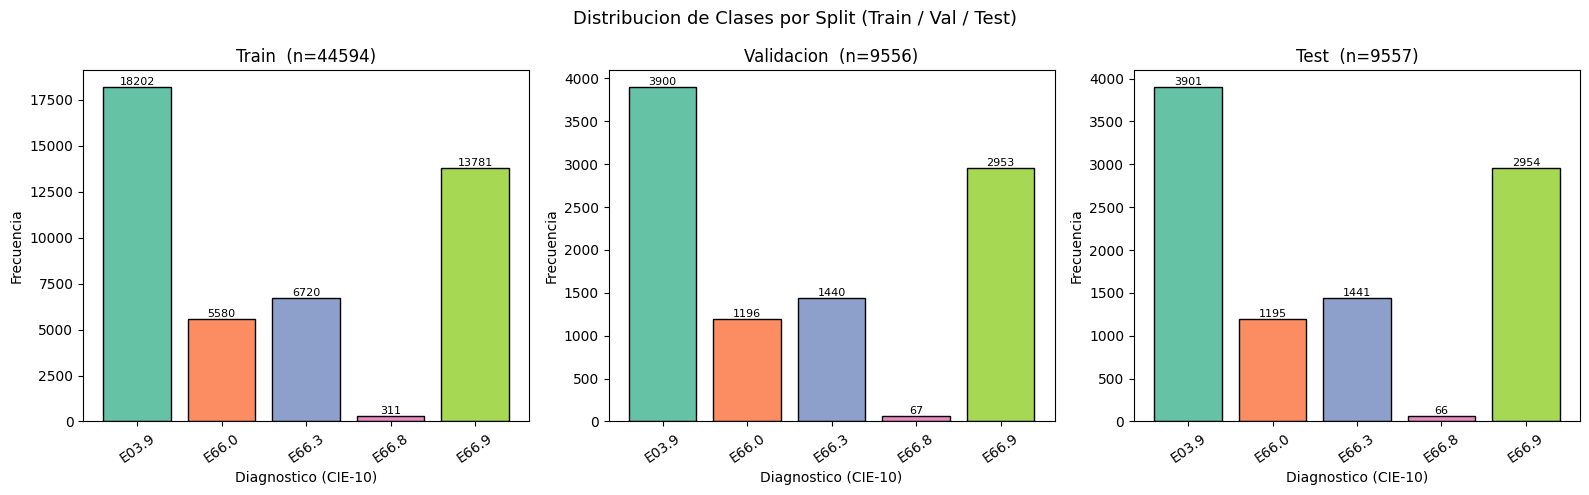

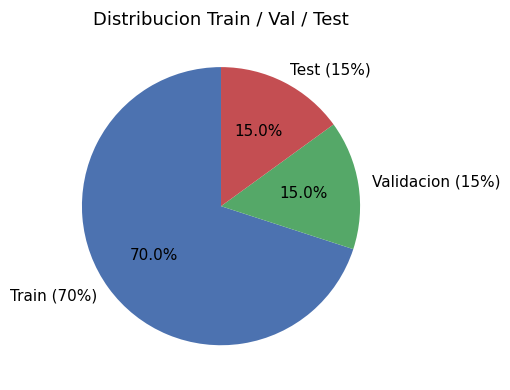

['label_encoder_target2.pkl']

In [ ]:
# ============================================================
# PUNTO 2 – ALEATORIZACIÓN Y DISTRIBUCIÓN TRAIN / VAL / TEST
# ============================================================

from sklearn.model_selection import train_test_split

# ============================================================
# 1. FILTRAR CLASES CON MUY POCOS REGISTROS
# ============================================================
MIN_MUESTRAS = 50

conteo_clases = df_clean['TARGET'].value_counts()
clases_validas = conteo_clases[conteo_clases >= MIN_MUESTRAS].index

df_filtrado = df_clean[df_clean['TARGET'].isin(clases_validas)].copy()

le_target2 = LabelEncoder()
df_filtrado['TARGET'] = le_target2.fit_transform(df_filtrado['TARGET'])

print('=' * 55)
print('CLASES CONSERVADAS')
print('=' * 55)
for i, cls_enc in enumerate(le_target2.classes_):
    cls_original = le_target.inverse_transform([cls_enc])[0]
    n = (df_filtrado['TARGET'] == i).sum()
    print('  ' + str(i) + ' -> ' + cls_original + ': ' + str(n) + ' registros')

print('\nRegistros antes del filtro: ' + str(len(df_clean)))
print('Registros despues del filtro: ' + str(len(df_filtrado)))
print('Clases conservadas: ' + str(df_filtrado['TARGET'].nunique()))

# ============================================================
# 2. SEPARAR FEATURES Y TARGET
# ============================================================
X = df_filtrado.drop(columns=['TARGET'])
y = df_filtrado['TARGET']

print('\nFeatures (X): ' + str(X.shape))
print('Target  (y): ' + str(y.shape))

# ============================================================
# 3. ALEATORIZACIÓN Y SPLIT 70% / 15% / 15%
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=y_temp
)

total = len(df_filtrado)
print('\n' + '=' * 55)
print('DISTRIBUCIÓN DEL DATASET')
print('=' * 55)
print('Total registros:    ' + str(total))
print('Train:              ' + str(len(X_train)) + '  (' + str(round(len(X_train)/total*100, 1)) + '%)')
print('Validacion:         ' + str(len(X_val))   + '  (' + str(round(len(X_val)/total*100, 1))   + '%)')
print('Test:               ' + str(len(X_test))  + '  (' + str(round(len(X_test)/total*100, 1))  + '%)')

# ============================================================
# 4. VERIFICAR PROPORCIÓN DE CLASES POR SPLIT
# ============================================================
print('\n' + '=' * 55)
print('PROPORCIÓN DE CLASES POR SPLIT (stratify)')
print('=' * 55)

splits = {'Train': y_train, 'Validacion': y_val, 'Test': y_test}

for nombre, y_split in splits.items():
    print('\n' + nombre + ':')
    conteo = y_split.value_counts().sort_index()
    for idx, cnt in conteo.items():
        clase = le_target.inverse_transform([le_target2.classes_[idx]])[0]
        print('  ' + clase + ': ' + str(cnt) + ' (' + str(round(cnt/len(y_split)*100, 1)) + '%)')

# ============================================================
# 5. VISUALIZACIÓN BARRAS POR SPLIT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores = plt.cm.Set2.colors

for ax, (nombre, y_split) in zip(axes, splits.items()):
    conteo = y_split.value_counts().sort_index()
    etiquetas = [le_target.inverse_transform([le_target2.classes_[i]])[0] for i in conteo.index]
    ax.bar(etiquetas, conteo.values, color=colores[:len(etiquetas)], edgecolor='black')
    titulo = nombre + '  (n=' + str(len(y_split)) + ')'
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Diagnostico (CIE-10)')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=35)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribucion de Clases por Split (Train / Val / Test)', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# 6. PIE CHART RESUMEN
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Train (70%)', 'Validacion (15%)', 'Test (15%)']
sizes  = [len(X_train), len(X_val), len(X_test)]
colors = ['#4C72B0', '#55A868', '#C44E52']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title('Distribucion Train / Val / Test', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# 7. GUARDAR SPLITS
# ============================================================
joblib.dump((X_train, X_val, X_test, y_train, y_val, y_test), 'splits.pkl')
joblib.dump(le_target2, 'label_encoder_target2.pkl')


TensorFlow version: 2.19.0
Numero de features: 17
Numero de clases:   5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,925 (195.02 KB)

 Trainable params: 48,965 (191.27 KB)

 Non-trainable params: 960 (3.75 KB)

Modelo compilado correctamente

Iniciando entrenamiento...

Epoch 1/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3841 - loss: 1.5201 - val_accuracy: 0.5523 - val_loss: 1.0866 - learning_rate: 0.0010
Epoch 2/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5281 - loss: 1.1424 - val_accuracy: 0.5686 - val_loss: 1.0628 - learning_rate: 0.0010
Epoch 3/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5431 - loss: 1.1101 - val_accuracy: 0.5778 - val_loss: 1.0421 - learning_rate: 0.0010
Epoch 4/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5536 - loss: 1.0895 - val_accuracy: 0.5842 - val_loss: 1.0269 - learning_rate: 0.0010
Epoch 5/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5595 - loss: 1.0775 - val_accuracy: 0.5908 - val_loss: 1.0116 - learning_rate: 0.0010
Epoch 6/100
697/697 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5680 - loss: 1.0623 - val_accuracy: 0.5963 - val_loss: 1.0036 - learning_rate: 0.0010
Epoch 7/100
697/697 ━━

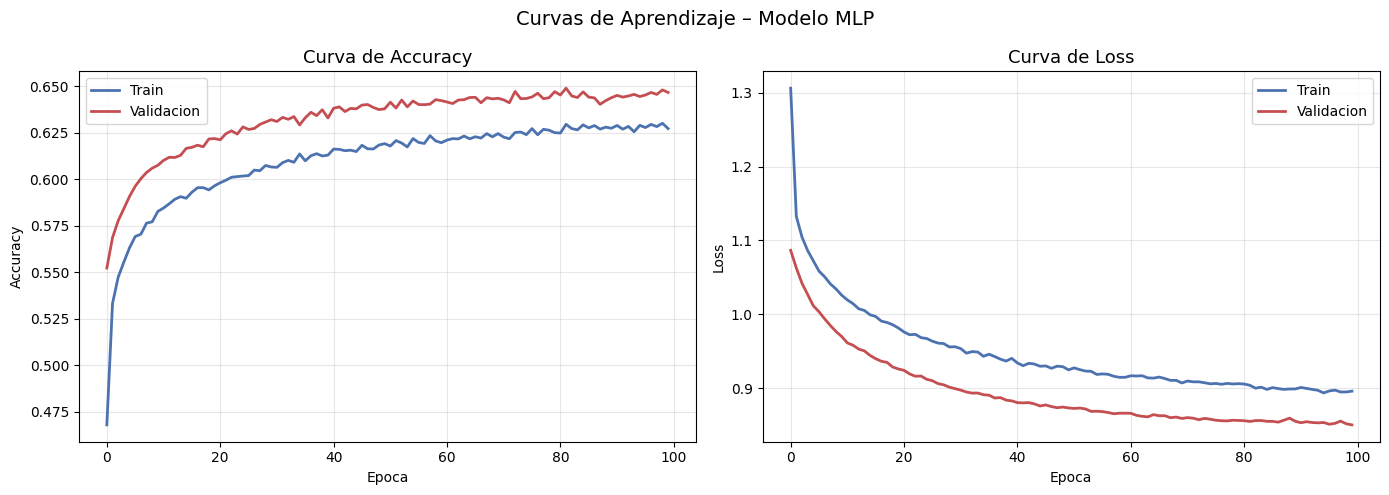

modelo_mlp.keras guardado


In [ ]:
# ============================================================
# PUNTO 3 – MODELO MLP PARA CLASIFICACIÓN DE DIAGNÓSTICOS
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt

print('TensorFlow version: ' + tf.__version__)

# ============================================================
# 1. CONFIGURACIÓN REPRODUCIBILIDAD
# ============================================================
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================
# 2. PARÁMETROS DEL MODELO
# ============================================================
N_FEATURES = X_train.shape[1]
N_CLASES   = df_filtrado['TARGET'].nunique()

print('Numero de features: ' + str(N_FEATURES))
print('Numero de clases:   ' + str(N_CLASES))

# ============================================================
# 3. ARQUITECTURA DEL MODELO MLP
# ============================================================
def crear_modelo(n_features, n_clases):
    model = keras.Sequential([

        # Capa de entrada
        layers.Input(shape=(n_features,)),

        # Capa oculta 1
        layers.Dense(256, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Capa oculta 2
        layers.Dense(128, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Capa oculta 3
        layers.Dense(64, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Capa oculta 4
        layers.Dense(32, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        # Capa de salida
        layers.Dense(n_clases, activation='softmax')
    ])
    return model

modelo = crear_modelo(N_FEATURES, N_CLASES)
modelo.summary()

# ============================================================
# 4. COMPILACIÓN DEL MODELO
# ============================================================
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Modelo compilado correctamente')

# ============================================================
# 5. CALLBACKS
# ============================================================
callbacks = [
    # Detiene el entrenamiento si val_loss no mejora en 10 épocas
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce el learning rate si val_loss se estanca
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# 6. ENTRENAMIENTO
# ============================================================
print('\nIniciando entrenamiento...\n')

history = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# 7. EVALUACIÓN EN TRAIN Y VALIDACIÓN
# ============================================================
print('\n' + '=' * 55)
print('EVALUACIÓN DEL MODELO')
print('=' * 55)

train_loss, train_acc = modelo.evaluate(X_train, y_train, verbose=0)
val_loss,   val_acc   = modelo.evaluate(X_val,   y_val,   verbose=0)

print('Train    — Loss: ' + str(round(train_loss, 4)) + '  |  Accuracy: ' + str(round(train_acc*100, 2)) + '%')
print('Val      — Loss: ' + str(round(val_loss,   4)) + '  |  Accuracy: ' + str(round(val_acc*100,   2)) + '%')

# ============================================================
# 8. CURVAS DE APRENDIZAJE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train',      color='#4C72B0', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validacion', color='#C44E52', linewidth=2)
axes[0].set_title('Curva de Accuracy', fontsize=13)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train',      color='#4C72B0', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validacion', color='#C44E52', linewidth=2)
axes[1].set_title('Curva de Loss', fontsize=13)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje – Modelo MLP', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 9. GUARDAR MODELO
# ============================================================
modelo.save('modelo_mlp.keras')
print('modelo_mlp.keras guardado')

4. Defina el conjunto óptimo de hiperparámetros de su modelo utilizando los datos de
validación, tenga en cuenta aspectos como el número de capas, número de unidades,
función de pérdida, método de inicialización, número de épocas, tamaño del lote, etc.


Trial 10 Complete [00h 01m 04s]
val_accuracy: 0.5407074093818665

Best val_accuracy So Far: 0.6302846670150757
Total elapsed time: 00h 10m 23s

MEJORES HIPERPARAMETROS ENCONTRADOS
n_capas:        3
unidades:       512
activacion:     tanh
inicializacion: glorot_uniform
dropout:        0.5
batch_norm:     True
learning_rate:  0.01
optimizador:    rmsprop

BUSQUEDA DE MEJOR BATCH SIZE
batch_size=32 -> val_accuracy=62.82%
batch_size=64 -> val_accuracy=63.3%
batch_size=128 -> val_accuracy=63.07%
batch_size=256 -> val_accuracy=62.71%

Mejor batch_size: 64

ENTRENAMIENTO MODELO FINAL OPTIMIZADO
Epoch 1/150
697/697 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4925 - loss: 1.2587 - val_accuracy: 0.5702 - val_loss: 1.0745 - learning_rate: 0.0100
Epoch 2/150
697/697 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5455 - loss: 1.1084 - val_accuracy: 0.5834 - val_loss: 1.0321 - learning_rate: 0.0100
Epoch 3/150
697/697 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5580 - loss: 1.0811 - val_accu

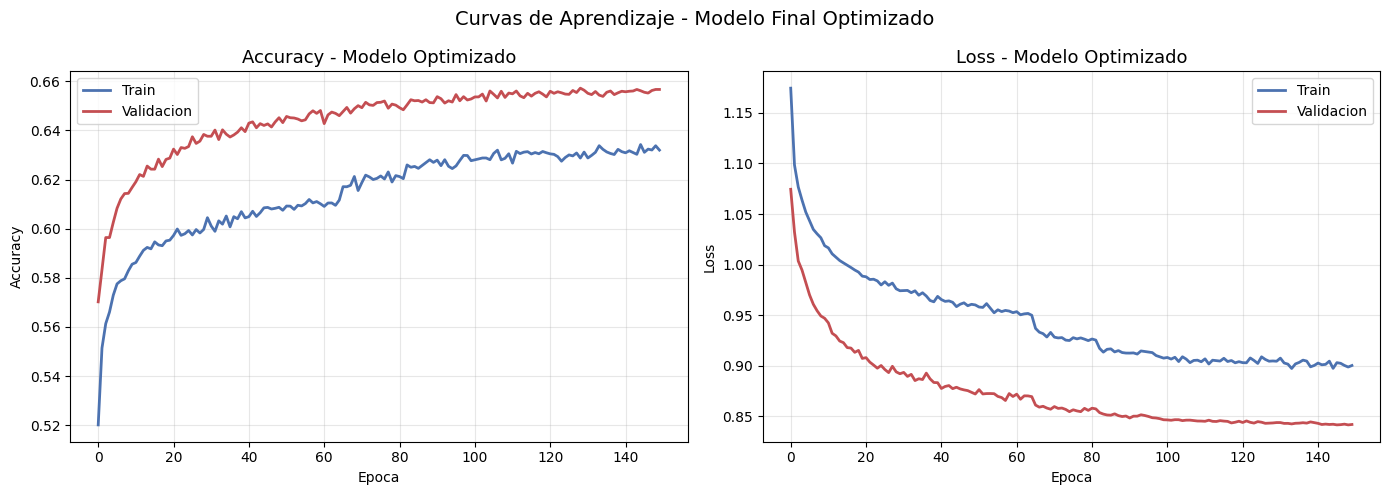

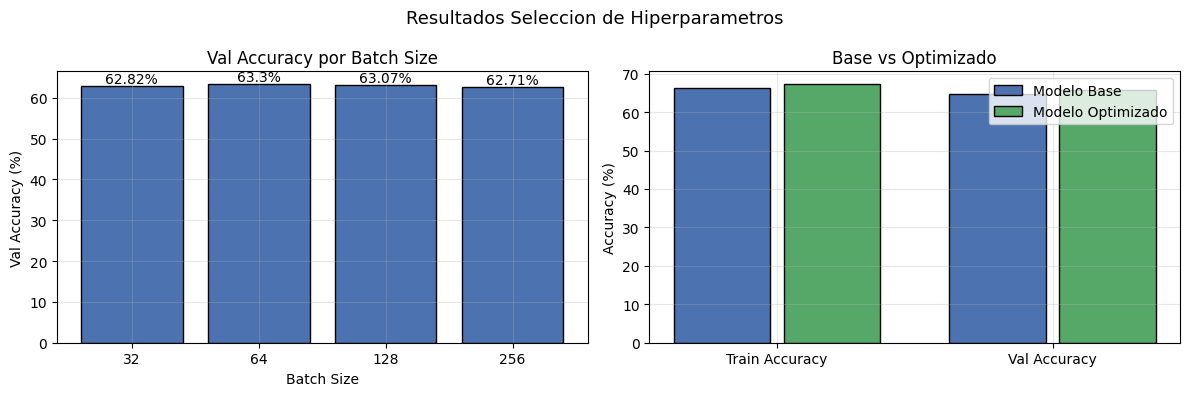

modelo_mlp_optimizado.keras guardado
mejores_hiperparametros.pkl guardado


In [ ]:
# ============================================================
# PUNTO 4 – SELECCIÓN DE HIPERPARÁMETROS
# ============================================================

!pip install keras-tuner -q

import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

tf.random.set_seed(42)
np.random.seed(42)

N_FEATURES = X_train.shape[1]
N_CLASES   = df_filtrado['TARGET'].nunique()

print('TensorFlow: ' + tf.__version__)
print('GPU disponible: ' + str(tf.config.list_physical_devices('GPU')))
print('N_FEATURES: ' + str(N_FEATURES))
print('N_CLASES:   ' + str(N_CLASES))

# ============================================================
# 1. DEFINIR ESPACIO DE BÚSQUEDA
# ============================================================
def build_model(hp):

    model = keras.Sequential()
    model.add(layers.Input(shape=(N_FEATURES,)))

    n_capas        = hp.Int('n_capas',          min_value=2, max_value=4, step=1)
    unidades       = hp.Choice('unidades',      values=[64, 128, 256, 512])
    activacion     = hp.Choice('activacion',    values=['relu', 'tanh', 'elu'])
    inicializacion = hp.Choice('inicializacion', values=['he_normal', 'glorot_uniform', 'he_uniform'])
    dropout        = hp.Float('dropout',        min_value=0.1, max_value=0.5, step=0.1)
    usar_batchnorm = hp.Boolean('batch_norm')
    lr             = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0005, 0.0001])
    optimizador    = hp.Choice('optimizador',   values=['adam', 'rmsprop', 'sgd'])

    for i in range(n_capas):
        model.add(layers.Dense(
            units=max(unidades // (2**i), 32),
            kernel_initializer=inicializacion
        ))
        if usar_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation(activacion))
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(N_CLASES, activation='softmax'))

    if optimizador == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif optimizador == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ============================================================
# 2. CONFIGURAR EL TUNER
# ============================================================
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    num_initial_points=3,
    directory='tuner_resultados',
    project_name='mlp_diagnosticos',
    overwrite=True
)

tuner.search_space_summary()

# ============================================================
# 3. EJECUTAR LA BÚSQUEDA
# ============================================================
callbacks_tuner = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print('Iniciando busqueda de hiperparametros...')
print('10 trials x 20 epocas — aprox 5-8 minutos con GPU\n')

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks_tuner,
    verbose=1
)

# ============================================================
# 4. MEJORES HIPERPARÁMETROS
# ============================================================
print('\n' + '=' * 55)
print('MEJORES HIPERPARAMETROS ENCONTRADOS')
print('=' * 55)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print('n_capas:        ' + str(best_hp.get('n_capas')))
print('unidades:       ' + str(best_hp.get('unidades')))
print('activacion:     ' + str(best_hp.get('activacion')))
print('inicializacion: ' + str(best_hp.get('inicializacion')))
print('dropout:        ' + str(best_hp.get('dropout')))
print('batch_norm:     ' + str(best_hp.get('batch_norm')))
print('learning_rate:  ' + str(best_hp.get('learning_rate')))
print('optimizador:    ' + str(best_hp.get('optimizador')))

# ============================================================
# 5. BÚSQUEDA DE MEJOR BATCH SIZE
# ============================================================
print('\n' + '=' * 55)
print('BUSQUEDA DE MEJOR BATCH SIZE')
print('=' * 55)

callbacks_batch = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

resultados_batch = {}
for bs in [32, 64, 128, 256]:
    modelo_tmp = tuner.hypermodel.build(best_hp)
    hist = modelo_tmp.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=bs,
        callbacks=callbacks_batch,
        verbose=0
    )
    val_acc = max(hist.history['val_accuracy'])
    resultados_batch[bs] = round(val_acc * 100, 2)
    print('batch_size=' + str(bs) + ' -> val_accuracy=' + str(resultados_batch[bs]) + '%')

mejor_batch = max(resultados_batch, key=resultados_batch.get)
print('\nMejor batch_size: ' + str(mejor_batch))

# ============================================================
# 6. ENTRENAMIENTO MODELO FINAL OPTIMIZADO
# ============================================================
print('\n' + '=' * 55)
print('ENTRENAMIENTO MODELO FINAL OPTIMIZADO')
print('=' * 55)

modelo_final = tuner.hypermodel.build(best_hp)

callbacks_final = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

history_final = modelo_final.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=mejor_batch,
    callbacks=callbacks_final,
    verbose=1
)

# ============================================================
# 7. COMPARACIÓN MODELO BASE VS OPTIMIZADO
# ============================================================
train_loss_b, train_acc_b = modelo.evaluate(X_train, y_train, verbose=0)
val_loss_b,   val_acc_b   = modelo.evaluate(X_val,   y_val,   verbose=0)

train_loss_f, train_acc_f = modelo_final.evaluate(X_train, y_train, verbose=0)
val_loss_f,   val_acc_f   = modelo_final.evaluate(X_val,   y_val,   verbose=0)

print('\n' + '=' * 55)
print('COMPARACION: MODELO BASE vs MODELO OPTIMIZADO')
print('=' * 55)
print('               Train Acc    Val Acc    Train Loss   Val Loss')
print('Modelo Base:   ' + str(round(train_acc_b*100,2)) + '%       '
      + str(round(val_acc_b*100,2)) + '%      '
      + str(round(train_loss_b,4)) + '        '
      + str(round(val_loss_b,4)))
print('Modelo Final:  ' + str(round(train_acc_f*100,2)) + '%       '
      + str(round(val_acc_f*100,2)) + '%      '
      + str(round(train_loss_f,4)) + '        '
      + str(round(val_loss_f,4)))

mejora = round((val_acc_f - val_acc_b)*100, 2)
print('\nMejora en val_accuracy: +' + str(mejora) + '%')

# ============================================================
# 8. CURVAS DE APRENDIZAJE MODELO FINAL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_final.history['accuracy'],     label='Train',      color='#4C72B0', linewidth=2)
axes[0].plot(history_final.history['val_accuracy'], label='Validacion', color='#C44E52', linewidth=2)
axes[0].set_title('Accuracy - Modelo Optimizado', fontsize=13)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_final.history['loss'],     label='Train',      color='#4C72B0', linewidth=2)
axes[1].plot(history_final.history['val_loss'], label='Validacion', color='#C44E52', linewidth=2)
axes[1].set_title('Loss - Modelo Optimizado', fontsize=13)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje - Modelo Final Optimizado', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 9. VISUALIZACIÓN COMPARATIVA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([str(k) for k in resultados_batch.keys()],
            resultados_batch.values(),
            color='#4C72B0', edgecolor='black')
axes[0].set_title('Val Accuracy por Batch Size', fontsize=12)
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Val Accuracy (%)')
axes[0].grid(True, alpha=0.3)
for p in axes[0].patches:
    axes[0].annotate(str(p.get_height()) + '%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

categorias = ['Train Accuracy', 'Val Accuracy']
base  = [round(train_acc_b*100,2), round(val_acc_b*100,2)]
final = [round(train_acc_f*100,2), round(val_acc_f*100,2)]
x = np.arange(len(categorias))
axes[1].bar(x - 0.2, base,  0.35, label='Modelo Base',       color='#4C72B0', edgecolor='black')
axes[1].bar(x + 0.2, final, 0.35, label='Modelo Optimizado', color='#55A868', edgecolor='black')
axes[1].set_title('Base vs Optimizado', fontsize=12)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categorias)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Resultados Seleccion de Hiperparametros', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# 10. GUARDAR MODELO Y RESULTADOS
# ============================================================
modelo_final.save('modelo_mlp_optimizado.keras')
joblib.dump(best_hp.values, 'mejores_hiperparametros.pkl')
print('modelo_mlp_optimizado.keras guardado')
print('mejores_hiperparametros.pkl guardado')

EVALUACION FINAL DEL MODELO
Train      — Accuracy: 67.24%  |  Loss: 0.7961
Validacion — Accuracy: 65.67%  |  Loss: 0.8413
Test       — Accuracy: 65.21%  |  Loss: 0.8433
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


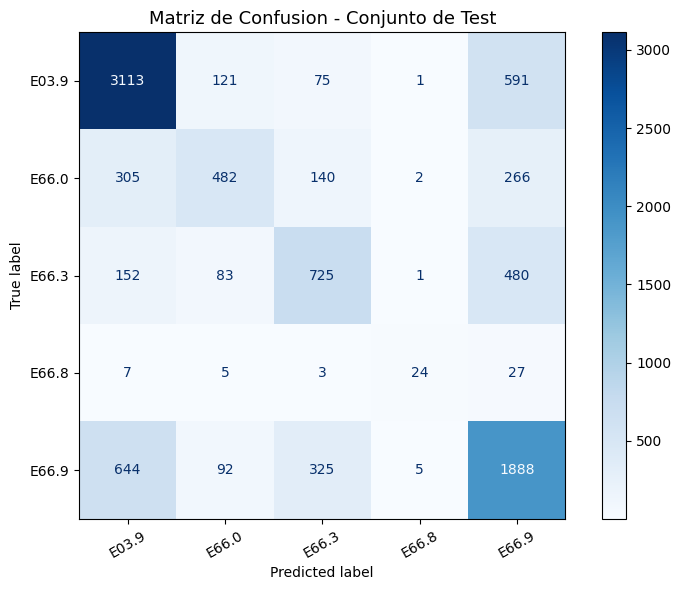


CONSOLIDACION FINAL DE RESULTADOS
  Conjunto  Accuracy (%)   Loss
     Train         67.24 0.7961
Validacion         65.67 0.8413
      Test         65.21 0.8433


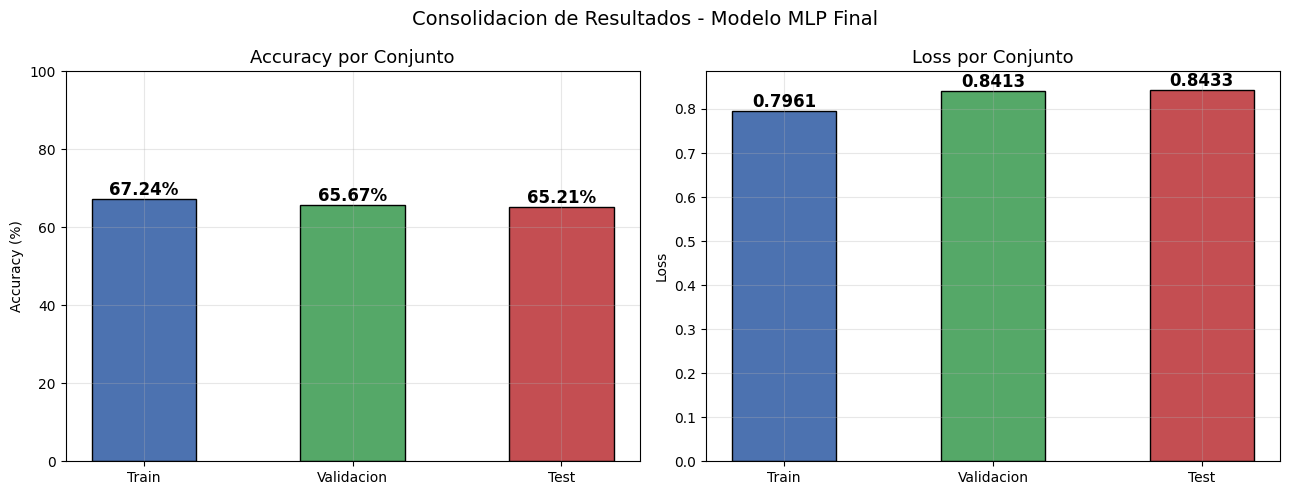

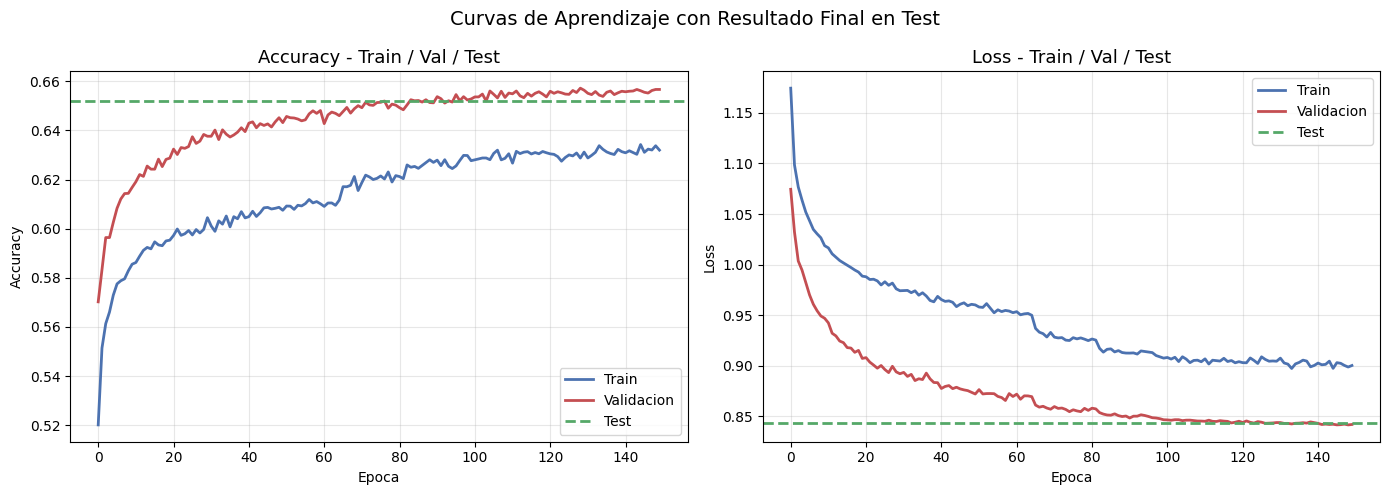

modelo_mlp_final.keras guardado correctamente


In [ ]:
# ============================================================
# PUNTO 5 – EVALUACIÓN FINAL EN TEST Y CONSOLIDACIÓN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# 1. EVALUACIÓN EN LOS 3 CONJUNTOS
# ============================================================
print('=' * 55)
print('EVALUACION FINAL DEL MODELO')
print('=' * 55)

train_loss, train_acc = modelo_final.evaluate(X_train, y_train, verbose=0)
val_loss,   val_acc   = modelo_final.evaluate(X_val,   y_val,   verbose=0)
test_loss,  test_acc  = modelo_final.evaluate(X_test,  y_test,  verbose=0)

print('Train      — Accuracy: ' + str(round(train_acc*100, 2)) + '%  |  Loss: ' + str(round(train_loss, 4)))
print('Validacion — Accuracy: ' + str(round(val_acc*100,   2)) + '%  |  Loss: ' + str(round(val_loss,   4)))
print('Test       — Accuracy: ' + str(round(test_acc*100,  2)) + '%  |  Loss: ' + str(round(test_loss,  4)))

# ============================================================
# 2. PREDICCIONES
# ============================================================
y_pred_proba = modelo_final.predict(X_test)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_real       = y_test.values

nombres_clases = [le_target.inverse_transform([le_target2.classes_[i]])[0]
                  for i in range(N_CLASES)]

# ============================================================
# 3. MATRIZ DE CONFUSIÓN
# ============================================================
cm = confusion_matrix(y_real, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=30)
ax.set_title('Matriz de Confusion - Conjunto de Test', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# 4. CONSOLIDACIÓN DE RESULTADOS (ACCURACY)
# ============================================================
print('\n' + '=' * 55)
print('CONSOLIDACION FINAL DE RESULTADOS')
print('=' * 55)

resumen = pd.DataFrame({
    'Conjunto':     ['Train', 'Validacion', 'Test'],
    'Accuracy (%)': [round(train_acc*100,2), round(val_acc*100,2), round(test_acc*100,2)],
    'Loss':         [round(train_loss,4),    round(val_loss,4),    round(test_loss,4)]
})
print(resumen.to_string(index=False))

# ============================================================
# 5. GRÁFICO CONSOLIDADO DE ACCURACY
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

conjuntos  = ['Train', 'Validacion', 'Test']
accuracies = [round(train_acc*100,2), round(val_acc*100,2), round(test_acc*100,2)]
losses     = [round(train_loss,4),    round(val_loss,4),    round(test_loss,4)]
colores    = ['#4C72B0', '#55A868', '#C44E52']

# Accuracy
bars = axes[0].bar(conjuntos, accuracies, color=colores, edgecolor='black', width=0.5)
axes[0].set_title('Accuracy por Conjunto', fontsize=13)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)
for bar, val in zip(bars, accuracies):
    axes[0].annotate(str(val) + '%',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Loss
bars2 = axes[1].bar(conjuntos, losses, color=colores, edgecolor='black', width=0.5)
axes[1].set_title('Loss por Conjunto', fontsize=13)
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
for bar, val in zip(bars2, losses):
    axes[1].annotate(str(val),
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle('Consolidacion de Resultados - Modelo MLP Final', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 6. CURVAS DE ACCURACY HISTÓRICAS (TRAIN vs VAL)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_final.history['accuracy'],     label='Train',      color='#4C72B0', linewidth=2)
axes[0].plot(history_final.history['val_accuracy'], label='Validacion', color='#C44E52', linewidth=2)
axes[0].axhline(y=test_acc, color='#55A868', linewidth=2, linestyle='--', label='Test')
axes[0].set_title('Accuracy - Train / Val / Test', fontsize=13)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_final.history['loss'],     label='Train',      color='#4C72B0', linewidth=2)
axes[1].plot(history_final.history['val_loss'], label='Validacion', color='#C44E52', linewidth=2)
axes[1].axhline(y=test_loss, color='#55A868', linewidth=2, linestyle='--', label='Test')
axes[1].set_title('Loss - Train / Val / Test', fontsize=13)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje con Resultado Final en Test', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 7. GUARDAR MODELO FINAL
# ============================================================
modelo_final.save('modelo_mlp_final.keras')
print('modelo_mlp_final.keras guardado correctamente')